# Exploración inicial del dataset de mantenimiento de bomba centrífuga

## Objetivo

Comprender la estructura, calidad y comportamiento físico de las variables del dataset antes de entrenar cualquier modelo de inteligencia artificial.

En esta etapa se revisarán:

- Dimensiones y columnas.
- Tipos de datos.
- Valores faltantes y duplicados.
- Estructura temporal y frecuencia de muestreo.
- Rangos estadísticos de los sensores.
- Distribución de las clases de falla.
- Comportamiento de las variables por condición operacional.
- Correlaciones y posibles limitaciones del dataset.

## Dataset

**Nombre:** Predictive Maintenance Dataset for CG-IPM-15 Pump  
**Archivo:** `MBG12_1sec_data.csv`  
**Fuente:** https://github.com/rajesh-amrita/pump_maintenance  
**Naturaleza:** Dataset sintético que emula una bomba centrífuga industrial Crompton Greaves CG-IPM-15.

> Los resultados obtenidos con este dataset no deben interpretarse como validación sobre una bomba industrial real.

In [3]:
from pathlib import Path

Path.cwd()

PosixPath('/home/cristian/proyectos/mantenimiento-ia/notebooks')

In [4]:
DATA_PATH = Path("../data/raw/MBG12_1sec_data.csv").resolve()

print(f"Ruta: {DATA_PATH}")
print(f"Existe: {DATA_PATH.exists()}")
print(f"Tamaño: {DATA_PATH.stat().st_size / 1024**2:.2f} MB")

Ruta: /home/cristian/proyectos/mantenimiento-ia/data/raw/MBG12_1sec_data.csv
Existe: True
Tamaño: 81.04 MB


## 1. Carga inicial del dataset

En esta sección se carga el archivo CSV en un DataFrame de pandas llamado `df`.

Después de la carga se comprueban:

- El número total de registros.
- El número total de columnas.
- Las primeras cinco filas del dataset.

Esta verificación permite confirmar que el archivo puede leerse correctamente y que sus dimensiones coinciden con las informadas por el autor.

In [5]:
import pandas as pd

df = pd.read_csv(DATA_PATH)

print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
df.head()

Filas: 259,200
Columnas: 28


,Timestamp,Phase1_Voltage,Phase2_Voltage,Phase3_Voltage,Phase1_Current,Phase2_Current,Phase3_Current,Active_Power,Reactive_Power,Power_Factor,...,Vibration_Y,Vibration_Z,Motor_Speed,Torque,Insulation_Resistance,Oil_Level,Current_Unbalance,THD_Current,Bearing_FFT_Harmonics,Failure_Code
0,01-01-2024 00:00,412.175353,408.162801,408.570136,1.874395,1.957055,1.981316,0.733226,0.463226,0.932878,...,1.281942,1.081712,2883.153262,2.874261,9.442286,90.848923,3.343506,5.175827,0.113170,0
1,01-01-2024 00:00,409.199354,412.971448,411.580914,2.132437,1.946194,2.157162,0.799914,0.490341,0.824553,...,1.275688,0.912586,2885.310069,2.826666,11.408233,96.224124,1.013638,5.284890,0.093601,0
2,01-01-2024 00:00,415.612188,411.836185,415.902939,2.111259,2.262882,2.206587,0.764388,0.461047,0.903768,...,1.194446,0.952529,2883.249692,2.774897,11.091204,87.449594,0.374193,5.521281,0.093808,0
3,01-01-2024 00:00,414.606107,416.305993,411.202729,1.824051,2.301688,2.044510,0.768818,0.501752,0.839548,...,1.027996,0.857446,2888.250034,2.267094,10.665598,88.313734,1.318789,4.987324,0.061005,0
4,01-01-2024 00:00,415.478886,415.708709,414.791577,1.859842,1.845668,1.759008,0.666581,0.455182,0.917878,...,0.697798,0.969252,2879.588059,2.679267,10.725658,89.382977,1.681082,6.643706,0.080141,0


## 2. Columnas y tipos de datos

Se identifican todas las columnas disponibles y el tipo de dato asignado por pandas.

Esta revisión permite separar:

- La variable temporal.
- Las variables numéricas de sensores.
- La etiqueta de condición o falla.
- Las columnas que podrían requerir conversión o limpieza.

In [6]:
resumen_columnas = pd.DataFrame({
    "Columna": df.columns,
    "Tipo de dato": df.dtypes.astype(str).values
})

resumen_columnas

,Columna,Tipo de dato
0,Timestamp,str
1,Phase1_Voltage,float64
2,Phase2_Voltage,float64
3,Phase3_Voltage,float64
4,Phase1_Current,float64
5,Phase2_Current,float64
6,Phase3_Current,float64
7,Active_Power,float64
8,Reactive_Power,float64
9,Power_Factor,float64


### Hallazgos sobre las columnas

El dataset contiene 28 columnas:

- Una variable temporal: `Timestamp`.
- Veintiséis variables numéricas de sensores.
- Una etiqueta de condición: `Failure_Code`.

Todas las variables de sensores fueron reconocidas como valores numéricos de tipo `float64`.

La columna `Failure_Code` fue reconocida como entero (`int64`), por lo que puede utilizarse como etiqueta de clasificación.

La columna `Timestamp` fue leída como texto (`str`). Será necesario convertirla explícitamente a formato de fecha y hora antes de realizar el análisis temporal.

## 3. Valores faltantes y registros duplicados

Se revisa si el dataset contiene:

- Celdas vacías o valores faltantes.
- Filas completamente duplicadas.
- El porcentaje de datos faltantes por variable.

Los valores faltantes pueden requerir eliminación, imputación o análisis adicional. Los duplicados completos podrían alterar las distribuciones y sesgar los resultados del modelo.

In [7]:
valores_faltantes = df.isna().sum()

calidad_datos = pd.DataFrame({
    "Valores faltantes": valores_faltantes,
    "Porcentaje (%)": (valores_faltantes / len(df) * 100).round(4)
})

duplicados = df.duplicated().sum()

display(calidad_datos)
print(f"Filas completamente duplicadas: {duplicados:,}")

,Valores faltantes,Porcentaje (%)
Timestamp,0,0.0
Phase1_Voltage,0,0.0
Phase2_Voltage,0,0.0
Phase3_Voltage,0,0.0
Phase1_Current,0,0.0
Phase2_Current,0,0.0
Phase3_Current,0,0.0
Active_Power,0,0.0
Reactive_Power,0,0.0
Power_Factor,0,0.0


Filas completamente duplicadas: 0


### Hallazgos sobre la calidad básica

No se encontraron valores faltantes en ninguna de las 28 columnas.

Tampoco se encontraron filas completamente duplicadas. Por lo tanto, en esta etapa no es necesario eliminar registros ni aplicar métodos de imputación.

Esta comprobación evalúa filas completas. Más adelante se revisarán posibles repeticiones en la marca temporal y comportamientos anómalos dentro de cada sensor.

## 4. Revisión de la variable temporal

La columna `Timestamp` se convierte de texto a fecha y hora para comprobar:

- Si existen fechas inválidas.
- La fecha inicial y final.
- El número de marcas temporales diferentes.
- Si los registros están ordenados cronológicamente.
- Cuántos registros comparten la misma marca temporal.

El archivo se describe como datos con resolución de un segundo. Sin embargo, las marcas temporales visibles solo muestran precisión hasta el minuto. Esta revisión permitirá verificar la consistencia de esa afirmación.

In [8]:
df["Timestamp"] = pd.to_datetime(
    df["Timestamp"],
    format="%d-%m-%Y %H:%M",
    errors="coerce"
)

registros_por_timestamp = df["Timestamp"].value_counts()

print(f"Fechas inválidas: {df['Timestamp'].isna().sum():,}")
print(f"Fecha inicial: {df['Timestamp'].min()}")
print(f"Fecha final: {df['Timestamp'].max()}")
print(f"Marcas temporales únicas: {df['Timestamp'].nunique():,}")
print(f"Orden cronológico: {df['Timestamp'].is_monotonic_increasing}")
print(f"Mínimo de registros por marca temporal: {registros_por_timestamp.min()}")
print(f"Máximo de registros por marca temporal: {registros_por_timestamp.max()}")

Fechas inválidas: 0
Fecha inicial: 2024-01-01 00:00:00
Fecha final: 2024-01-03 23:59:00
Marcas temporales únicas: 4,320
Orden cronológico: True
Mínimo de registros por marca temporal: 60
Máximo de registros por marca temporal: 60


### Hallazgos sobre la estructura temporal

No se encontraron fechas inválidas y los registros están ordenados cronológicamente.

El archivo abarca desde el 1 de enero de 2024 a las 00:00 hasta el 3 de enero de 2024 a las 23:59, lo que corresponde aproximadamente a tres días.

Se identificaron 4.320 marcas temporales únicas y cada una aparece exactamente 60 veces. La columna `Timestamp` solo conserva precisión hasta el minuto.

Aunque el autor describe el dataset como 180 días con resolución de un segundo, el contenido del CSV no coincide completamente con esa descripción:

- 259.200 muestras a una muestra por segundo equivalen a tres días.
- El archivo contiene 60 registros por minuto.
- Los segundos no están registrados explícitamente.
- No puede confirmarse únicamente con el CSV qué segundo corresponde a cada fila.

Por lo tanto, la frecuencia de un segundo se tratará como una característica declarada por el autor, pero no como una propiedad temporal plenamente verificable en el archivo.

## 5. Distribución de las clases de condición

Se calcula el número y porcentaje de registros asociados a cada código de condición.

Esta revisión permite determinar si existe desbalance entre la operación normal y las diferentes fallas. En mantenimiento industrial, un fuerte desbalance puede producir modelos con buena exactitud general, pero baja capacidad para detectar fallas poco frecuentes.

In [9]:
nombres_clases = {
    0: "Operación normal",
    1: "Desgaste de rodamiento",
    2: "Degradación del aislamiento",
    3: "Daño del impulsor / cavitación",
    4: "Condición de múltiples fallas"
}

distribucion_clases = (
    df["Failure_Code"]
    .value_counts()
    .sort_index()
    .rename_axis("Failure_Code")
    .reset_index(name="Registros")
)

distribucion_clases["Condición"] = distribucion_clases["Failure_Code"].map(nombres_clases)
distribucion_clases["Porcentaje (%)"] = (
    distribucion_clases["Registros"] / len(df) * 100
).round(2)

distribucion_clases[
    ["Failure_Code", "Condición", "Registros", "Porcentaje (%)"]
]

,Failure_Code,Condición,Registros,Porcentaje (%)
0,0,Operación normal,216000,83.33
1,1,Desgaste de rodamiento,14400,5.56
2,2,Degradación del aislamiento,11520,4.44
3,3,Daño del impulsor / cavitación,8640,3.33
4,4,Condición de múltiples fallas,8640,3.33


### Hallazgos sobre la distribución de clases

La clase dominante es la operación normal, con 216.000 registros, equivalentes al 83,33 % del dataset.

Las cuatro condiciones de falla representan en conjunto el 16,67 % restante. Las clases menos frecuentes son daño del impulsor/cavitación y condición de múltiples fallas, cada una con el 3,33 %.

Existe, por tanto, un desbalance considerable entre la operación normal y las condiciones de falla.

La exactitud global (`accuracy`) no será suficiente para evaluar los futuros modelos. Será necesario analizar el desempeño individual por clase, especialmente el `recall`, debido a que un falso negativo representa una falla que el sistema no detecta.

### Visualización de la distribución de clases

Se representa el porcentaje de registros correspondiente a cada condición operacional. Esta gráfica permite observar visualmente el desbalance entre la operación normal y las diferentes clases de falla.

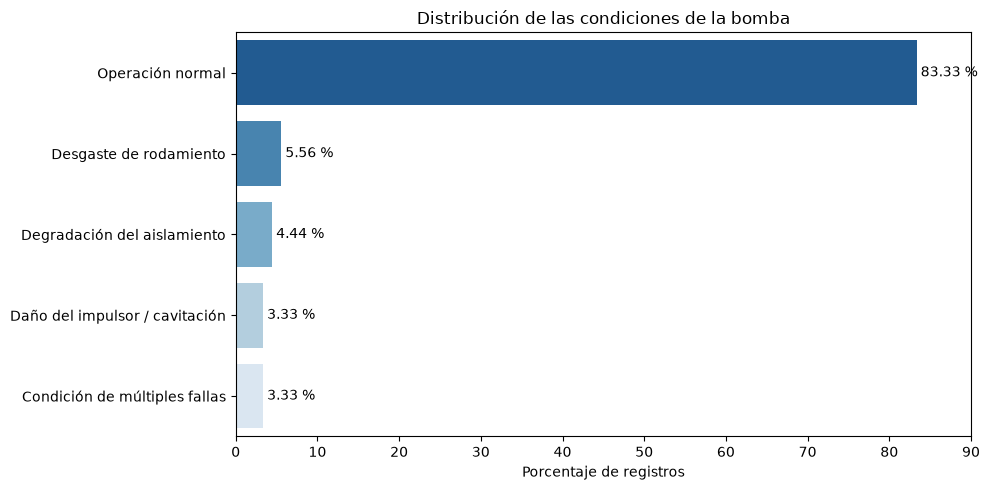

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=distribucion_clases,
    x="Porcentaje (%)",
    y="Condición",
    hue="Condición",
    legend=False,
    palette="Blues_r"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f %%", padding=3)

plt.title("Distribución de las condiciones de la bomba")
plt.xlabel("Porcentaje de registros")
plt.ylabel("")
plt.xlim(0, 90)
plt.tight_layout()
plt.show()

## 6. Secuencia temporal de las condiciones

Se identifican los bloques consecutivos de cada código de condición a lo largo del dataset.

El objetivo es determinar si existen múltiples episodios independientes de cada falla o si cada clase aparece solamente una vez como un segmento continuo.

Esta diferencia es fundamental para definir posteriormente una estrategia válida de entrenamiento, validación y prueba.

In [11]:
cambio_condicion = df["Failure_Code"].ne(df["Failure_Code"].shift())
id_bloque = cambio_condicion.cumsum()

bloques_condicion = (
    df.assign(Bloque=id_bloque)
    .groupby("Bloque")
    .agg(
        Failure_Code=("Failure_Code", "first"),
        Inicio=("Timestamp", "first"),
        Fin=("Timestamp", "last"),
        Registros=("Failure_Code", "size")
    )
    .reset_index(drop=True)
)

bloques_condicion["Condición"] = bloques_condicion["Failure_Code"].map(
    nombres_clases
)

bloques_condicion[
    ["Failure_Code", "Condición", "Inicio", "Fin", "Registros"]
]

,Failure_Code,Condición,Inicio,Fin,Registros
0,0,Operación normal,2024-01-01 00:00:00,2024-01-03 11:59:00,216000
1,1,Desgaste de rodamiento,2024-01-03 12:00:00,2024-01-03 15:59:00,14400
2,2,Degradación del aislamiento,2024-01-03 16:00:00,2024-01-03 19:11:00,11520
3,3,Daño del impulsor / cavitación,2024-01-03 19:12:00,2024-01-03 21:35:00,8640
4,4,Condición de múltiples fallas,2024-01-03 21:36:00,2024-01-03 23:59:00,8640


### Hallazgos sobre la secuencia de condiciones

El dataset está organizado en cinco bloques consecutivos:

1. Operación normal.
2. Desgaste de rodamiento.
3. Degradación del aislamiento.
4. Daño del impulsor o cavitación.
5. Condición de múltiples fallas.

Cada clase aparece exactamente una vez y no vuelve a repetirse posteriormente.

Por lo tanto, el dataset no contiene múltiples episodios independientes de cada falla. Una división aleatoria de registros podría colocar muestras muy similares del mismo episodio tanto en entrenamiento como en prueba, generando métricas excesivamente optimistas.

Además, una separación estrictamente temporal tampoco permitiría entrenar todas las clases, porque las fallas aparecen únicamente al final y en un orden fijo.

El dataset se utilizará inicialmente para exploración, clasificación demostrativa y desarrollo de la arquitectura. No se considerará evidencia suficiente de capacidad predictiva industrial.

## 7. Estadísticas descriptivas de los sensores

Se calculan las principales estadísticas de las 26 variables numéricas de sensores:

- Media.
- Desviación estándar.
- Valor mínimo.
- Percentiles 25 %, 50 % y 75 %.
- Valor máximo.

Este análisis permite detectar rangos inusuales, variables con poca variación y posibles valores extremos.

Las unidades todavía no han sido confirmadas por la documentación del dataset. Por ello, los valores se conservarán en las unidades originales del archivo y no se interpretarán físicamente como voltios, amperios, bar, grados Celsius u otras unidades hasta contar con evidencia suficiente.

In [12]:
columnas_sensores = [
    columna
    for columna in df.columns
    if columna not in ["Timestamp", "Failure_Code"]
]

estadisticas_sensores = (
    df[columnas_sensores]
    .describe()
    .transpose()
    .round(3)
)

estadisticas_sensores

,count,mean,std,min,25%,50%,75%,max
Phase1_Voltage,259200.0,415.007,2.995,401.563,412.986,415.003,417.038,428.815
Phase2_Voltage,259200.0,412.996,3.002,399.029,410.970,412.997,415.023,425.590
Phase3_Voltage,259200.0,414.005,3.004,400.038,411.981,414.008,416.038,427.994
Phase1_Current,259200.0,2.004,0.162,1.271,1.900,2.001,2.103,3.725
Phase2_Current,259200.0,2.000,0.150,1.319,1.899,2.000,2.101,2.712
Phase3_Current,259200.0,2.000,0.150,1.327,1.899,1.999,2.101,2.684
Active_Power,259200.0,0.751,0.052,0.457,0.716,0.750,0.785,1.105
Reactive_Power,259200.0,0.450,0.030,0.302,0.430,0.450,0.470,0.589
Power_Factor,259200.0,0.850,0.030,0.714,0.830,0.850,0.870,0.983
Frequency,259200.0,50.000,0.100,49.502,49.932,50.000,50.067,50.451


### Hallazgos sobre las estadísticas descriptivas

Todas las variables de sensores contienen 259.200 observaciones, lo que confirma la ausencia de valores faltantes.

La mayoría de las variables presenta un rango central relativamente estable, pero algunas muestran valores mínimos o máximos alejados de sus respectivos percentiles centrales.

Entre las variables que requieren revisión por condición se encuentran:

- Temperatura del rodamiento.
- Presión de salida.
- Caudal.
- Vibraciones en los tres ejes.
- Resistencia de aislamiento.
- Desbalance de corriente.
- Distorsión armónica de corriente.
- Armónicos FFT del rodamiento.

Estos valores extremos no se eliminarán automáticamente, porque pueden corresponder a patrones de falla introducidos intencionalmente en el dataset sintético.

Las estadísticas globales mezclan operación normal y fallas. Por ello, el siguiente paso será comparar cada sensor entre las cinco condiciones.

## 8. Comparación de sensores por condición

Se calcula la media de cada sensor para cada código de condición.

El objetivo es identificar qué variables fueron modificadas en el dataset sintético para representar:

- Operación normal.
- Desgaste de rodamiento.
- Degradación del aislamiento.
- Daño del impulsor o cavitación.
- Condición de múltiples fallas.

Esta comparación es descriptiva. Una diferencia de medias no demuestra por sí sola una relación causal ni garantiza que el mismo patrón aparezca en una bomba real.

In [13]:
medias_por_condicion = (
    df.groupby("Failure_Code")[columnas_sensores]
    .mean()
    .transpose()
    .rename(columns=nombres_clases)
    .round(3)
)

medias_por_condicion


Failure_Code,Operación normal,Desgaste de rodamiento,Degradación del aislamiento,Daño del impulsor / cavitación,Condición de múltiples fallas
Phase1_Voltage,415.011,415.007,414.963,415.001,414.978
Phase2_Voltage,412.997,412.995,412.988,413.001,412.996
Phase3_Voltage,414.006,413.954,414.001,414.045,414.012
Phase1_Current,2.004,2.006,2.000,2.001,2.000
Phase2_Current,2.000,2.001,2.000,2.000,1.998
Phase3_Current,2.000,1.998,2.000,1.999,2.003
Active_Power,0.751,0.752,0.749,0.750,0.750
Reactive_Power,0.450,0.450,0.450,0.450,0.450
Power_Factor,0.850,0.850,0.849,0.850,0.850
Frequency,50.000,50.000,50.001,49.998,49.999


### Hallazgos sobre los sensores por condición

La comparación de medias muestra que las clases fueron construidas mediante cambios marcados en grupos específicos de variables.

**Desgaste de rodamiento**

- Aumento de la temperatura del rodamiento.
- Aumento de las vibraciones en los ejes X e Y.
- Aumento de los armónicos FFT asociados al rodamiento.

Este patrón es coherente conceptualmente con una condición mecánica de rodamiento, aunque las unidades y el método de generación no están documentados.

**Degradación del aislamiento**

- Disminución considerable de la resistencia de aislamiento.
- Aumento del desbalance de corriente.
- Aumento de la distorsión armónica de corriente.

Los valores medios de algunas variables son números exactos, lo que sugiere que la condición fue generada mediante reglas sintéticas directas.

**Daño del impulsor o cavitación**

- Disminución de la presión de salida.
- Disminución del caudal.
- La presión de entrada permanece prácticamente igual.

El nombre de la clase combina daño del impulsor y cavitación, dos fenómenos que no necesariamente son equivalentes. El dataset no permite separarlos.

**Condición de múltiples fallas**

- El cambio medio más evidente aparece en la vibración Z.
- No se observa una combinación clara de los patrones de rodamiento, aislamiento e impulsor.

Por esta razón, la interpretación de la clase de múltiples fallas debe mantenerse bajo revisión.

Las restantes variables presentan medias muy similares entre las cinco clases. Esto indica que la clasificación probablemente dependerá de un grupo reducido de sensores y podría resultar artificialmente sencilla.

### Cambio porcentual respecto a la operación normal

Se calcula el cambio porcentual de la media de cada sensor frente a su media durante la operación normal.

Para facilitar la interpretación, se muestran únicamente las variables cuyo cambio absoluto máximo supera el 10 % en alguna condición.

Esta gráfica permite identificar qué sensores diferencian principalmente cada clase sintética.

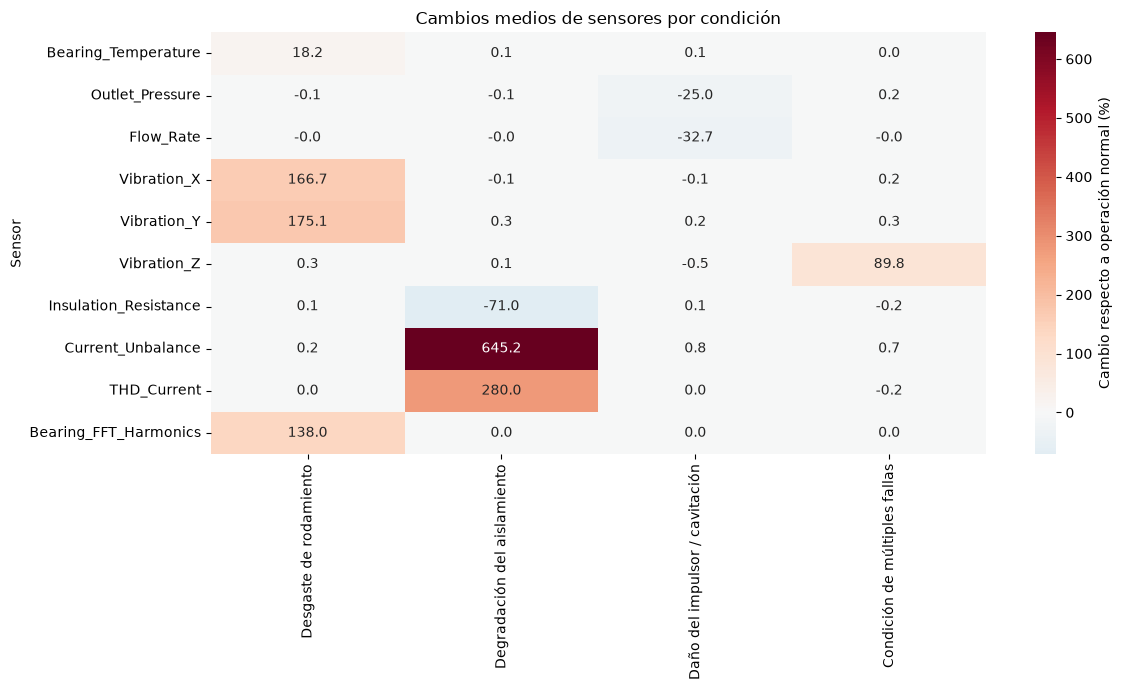

In [14]:
media_normal = medias_por_condicion["Operación normal"]

cambio_porcentual = (
    medias_por_condicion
    .drop(columns="Operación normal")
    .sub(media_normal, axis=0)
    .div(media_normal, axis=0)
    .mul(100)
)

variables_relevantes = cambio_porcentual.abs().max(axis=1) > 10
cambios_relevantes = cambio_porcentual.loc[variables_relevantes]

plt.figure(figsize=(12, 7))

sns.heatmap(
    cambios_relevantes,
    annot=True,
    fmt=".1f",
    cmap="RdBu_r",
    center=0,
    cbar_kws={"label": "Cambio respecto a operación normal (%)"}
)

plt.title("Cambios medios de sensores por condición")
plt.xlabel("")
plt.ylabel("Sensor")
plt.tight_layout()
plt.show()

### Interpretación de los cambios porcentuales

La visualización identifica diez variables con cambios superiores al 10 % respecto a la operación normal.

Cada condición presenta un patrón específico:

- El desgaste de rodamiento se concentra en temperatura del rodamiento, vibraciones X/Y y armónicos FFT.
- La degradación del aislamiento se concentra en resistencia de aislamiento, desbalance de corriente y THD.
- El daño del impulsor o cavitación se concentra en presión de salida y caudal.
- La condición de múltiples fallas se concentra únicamente en vibración Z.

Las variables asociadas a una condición permanecen casi sin cambios en las demás. Esto indica una separación sintética muy estructurada entre las clases.

En particular, la etiqueta de múltiples fallas no representa una combinación visible de las otras tres condiciones, por lo que probablemente funciona como una cuarta anomalía independiente en vibración Z.

Estos patrones podrían facilitar excesivamente la clasificación. Para evaluar esta posibilidad se revisará la variabilidad interna de los sensores dentro de cada clase.

## 9. Variabilidad de los sensores críticos por condición

Se calcula la desviación estándar de los sensores que presentan cambios relevantes entre clases.

La desviación estándar permite medir cuánto varían los registros dentro de cada condición. Valores muy bajos o iguales a cero pueden indicar que el generador sintético asignó valores fijos o reglas demasiado deterministas.

Un modelo entrenado con patrones deterministas podría obtener resultados elevados sin aprender el comportamiento complejo de una bomba real.

In [15]:
sensores_criticos = cambios_relevantes.index.tolist()

desviacion_por_condicion = (
    df.groupby("Failure_Code")[sensores_criticos]
    .std()
    .transpose()
    .rename(columns=nombres_clases)
    .round(4)
)

desviacion_por_condicion

Failure_Code,Operación normal,Desgaste de rodamiento,Degradación del aislamiento,Daño del impulsor / cavitación,Condición de múltiples fallas
Bearing_Temperature,1.9958,6.1355,1.9934,1.9984,1.9980
Outlet_Pressure,0.3000,0.3018,0.2996,0.5899,0.3027
Flow_Rate,0.2999,0.3019,0.3069,1.9140,0.3047
Vibration_X,0.2994,1.1992,0.3012,0.3008,0.3001
Vibration_Y,0.2497,1.0426,0.2504,0.2488,0.2494
Vibration_Z,0.1997,0.1999,0.2006,0.2039,0.5715
Insulation_Resistance,0.9997,0.9958,1.2126,0.9943,1.0017
Current_Unbalance,0.9658,0.9635,5.7743,0.9819,0.9604
THD_Current,1.0006,1.0063,6.3517,1.0020,0.9967
Bearing_FFT_Harmonics,0.0289,0.1603,0.0289,0.0288,0.0291


### Hallazgos sobre la variabilidad

Los sensores críticos conservan variabilidad dentro de todas las condiciones, por lo que las clases no fueron generadas únicamente mediante valores constantes.

No obstante, en cada falla aumenta tanto la media como la dispersión de las variables asociadas:

- En desgaste de rodamiento aumenta especialmente la variabilidad de la temperatura, vibración X/Y y armónicos FFT.
- En degradación del aislamiento aumenta la variabilidad de la resistencia de aislamiento, desbalance de corriente y THD.
- En daño del impulsor o cavitación aumenta notablemente la variabilidad de la presión de salida y el caudal.
- En múltiples fallas aumenta la variabilidad de la vibración Z.

El generador sintético parece modificar simultáneamente la ubicación y la dispersión de distribuciones específicas para construir cada clase.

El siguiente análisis visualizará si estas distribuciones se superponen o si las condiciones están casi completamente separadas.

## 10. Separación de las distribuciones por condición

Se comparan cuatro sensores representativos:

- `Vibration_X` para desgaste de rodamiento.
- `Insulation_Resistance` para degradación del aislamiento.
- `Flow_Rate` para daño del impulsor o cavitación.
- `Vibration_Z` para múltiples fallas.

Los diagramas de caja permiten observar la mediana, dispersión y superposición entre clases.

Para que la visualización sea más eficiente, se toma una muestra reproducible de hasta 3.000 registros por condición. Esta muestra se utiliza únicamente para la gráfica y no modifica el DataFrame original.

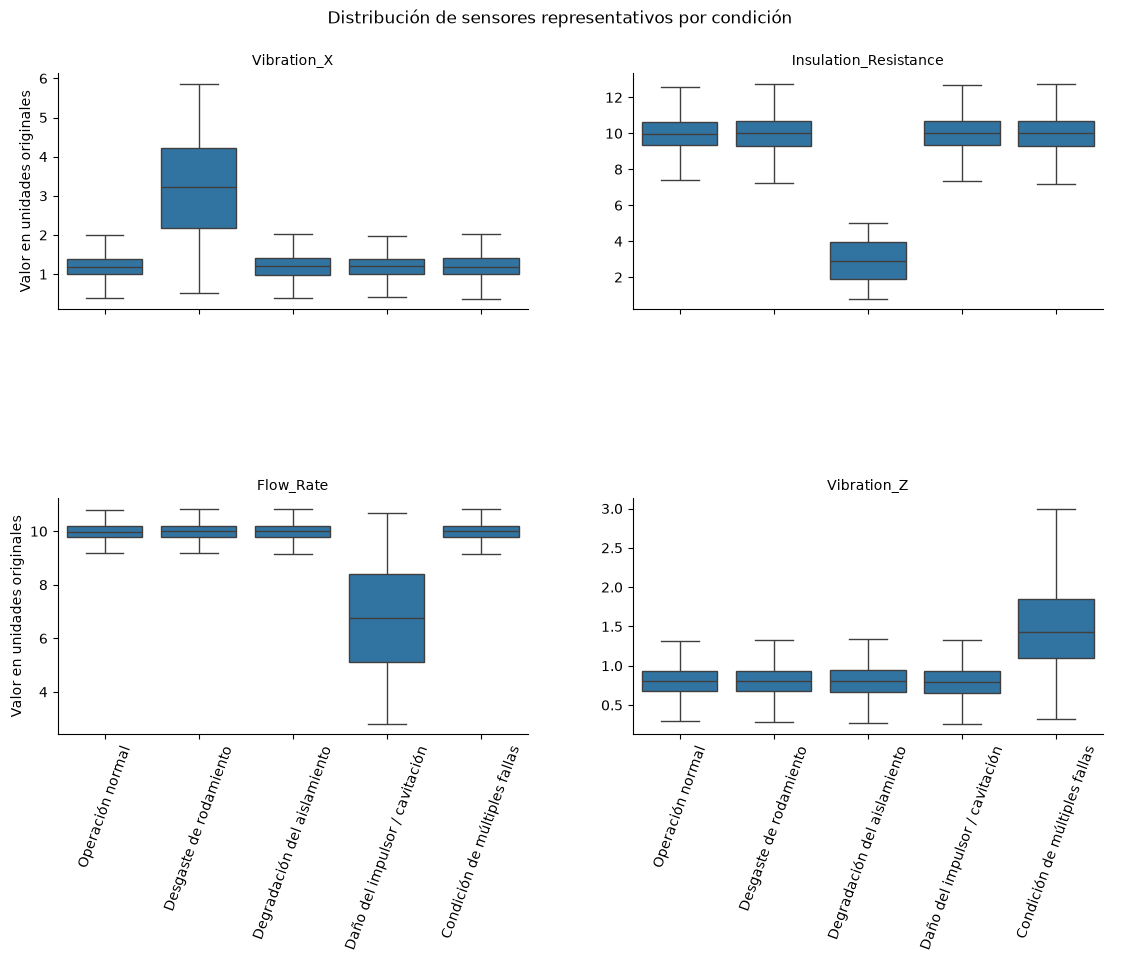

In [16]:
sensores_representativos = [
    "Vibration_X",
    "Insulation_Resistance",
    "Flow_Rate",
    "Vibration_Z"
]

muestra_grafica = (
    df.groupby("Failure_Code", group_keys=False)
    .sample(n=3000, random_state=42)
    .copy()
)

muestra_grafica["Condición"] = muestra_grafica["Failure_Code"].map(
    nombres_clases
)

datos_largos = muestra_grafica.melt(
    id_vars="Condición",
    value_vars=sensores_representativos,
    var_name="Sensor",
    value_name="Valor"
)

grafica = sns.catplot(
    data=datos_largos,
    x="Condición",
    y="Valor",
    col="Sensor",
    col_wrap=2,
    kind="box",
    sharey=False,
    showfliers=False,
    height=4,
    aspect=1.4
)

grafica.set_titles("{col_name}")
grafica.set_axis_labels("", "Valor en unidades originales")

for eje in grafica.axes.flatten():
    eje.tick_params(axis="x", rotation=70)

grafica.figure.subplots_adjust(top=0.9, hspace=0.8)
grafica.figure.suptitle("Distribución de sensores representativos por condición")

plt.show()

### Hallazgos sobre la separación de distribuciones

Los diagramas de caja muestran que cada condición puede diferenciarse mediante un sensor representativo:

- `Vibration_X` aumenta durante el desgaste de rodamiento.
- `Insulation_Resistance` disminuye durante la degradación del aislamiento.
- `Flow_Rate` disminuye durante el daño del impulsor o cavitación.
- `Vibration_Z` aumenta durante la condición de múltiples fallas.

Las cuatro variables permanecen prácticamente iguales a la operación normal cuando están asociadas a otras clases.

Aunque existe cierto solapamiento en los extremos de las distribuciones, sus rangos centrales están claramente separados. Esto sugiere que un conjunto de reglas simples o un árbol de poca profundidad podría alcanzar un desempeño elevado.

Por tanto, un modelo complejo no necesariamente demostraría mayor inteligencia; podría limitarse a reproducir los umbrales utilizados por el generador sintético.

## 11. Evolución temporal de los sensores representativos

Se agrupan los 60 registros que comparten cada marca temporal mediante su valor medio.

Después se visualiza la evolución de cuatro sensores representativos durante los tres días contenidos en el archivo.

Esta agregación se utiliza porque el campo `Timestamp` solo conserva precisión hasta el minuto, aunque cada minuto contiene 60 observaciones.

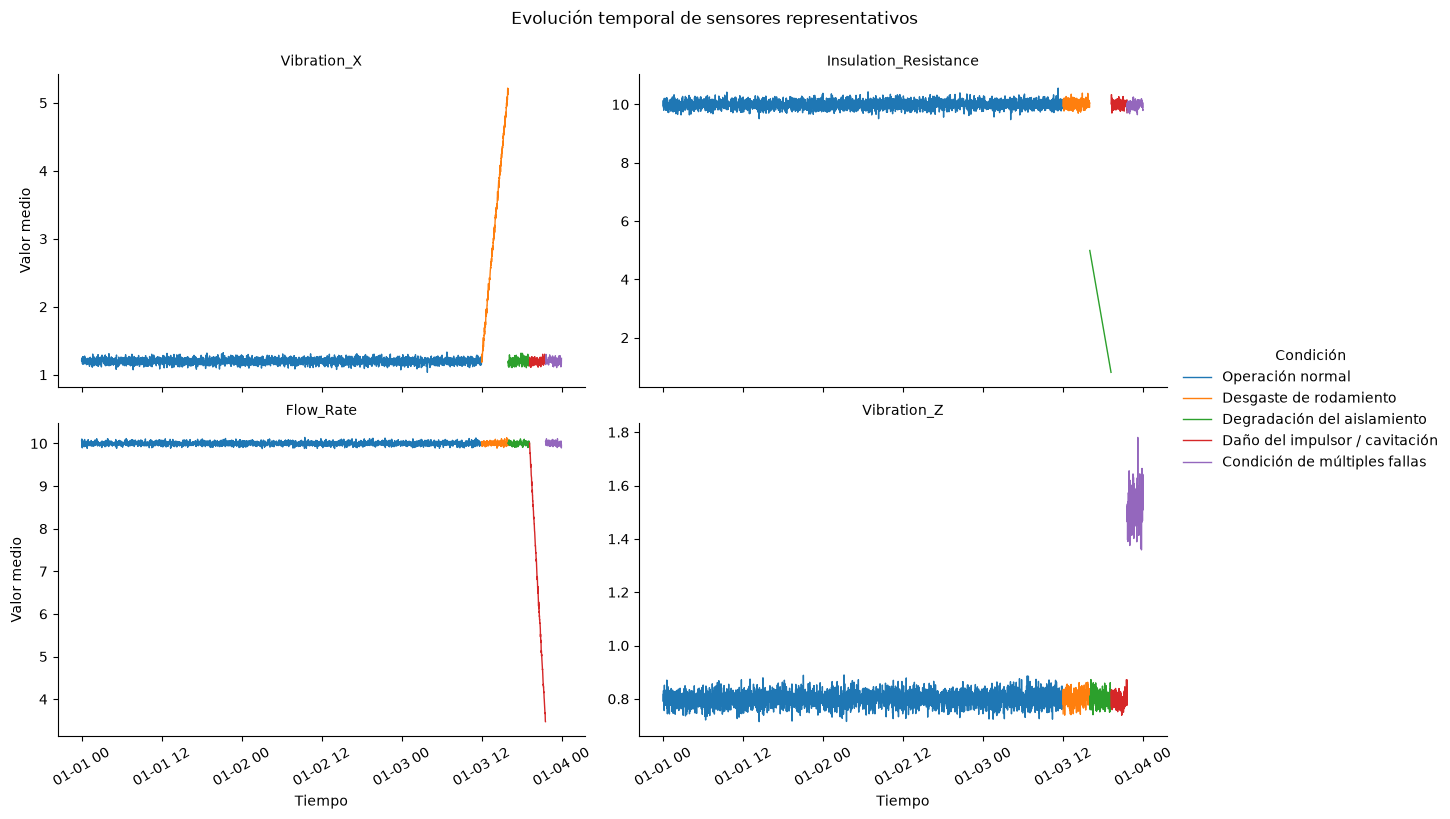

In [18]:
datos_temporales = (
    df.groupby("Timestamp")[
        sensores_representativos + ["Failure_Code"]
    ]
    .agg({
        **{sensor: "mean" for sensor in sensores_representativos},
        "Failure_Code": "first"
    })
    .reset_index()
)

datos_temporales["Condición"] = datos_temporales["Failure_Code"].map(
    nombres_clases
)

datos_temporales_largos = datos_temporales.melt(
    id_vars=["Timestamp", "Failure_Code", "Condición"],
    value_vars=sensores_representativos,
    var_name="Sensor",
    value_name="Valor medio por minuto"
)

grafica_temporal = sns.relplot(
    data=datos_temporales_largos,
    x="Timestamp",
    y="Valor medio por minuto",
    hue="Condición",
    col="Sensor",
    col_wrap=2,
    kind="line",
    facet_kws={"sharey": False},
    height=4,
    aspect=1.5,
    linewidth=1
)

grafica_temporal.set_titles("{col_name}")
grafica_temporal.set_axis_labels("Tiempo", "Valor medio")
grafica_temporal.figure.subplots_adjust(top=0.9)
grafica_temporal.figure.suptitle(
    "Evolución temporal de sensores representativos"
)

for eje in grafica_temporal.axes.flatten():
    eje.tick_params(axis="x", rotation=30)

plt.show()

### Hallazgos sobre la evolución temporal

Las condiciones no fueron construidas únicamente mediante cambios instantáneos y constantes.

Durante algunos bloques se observan tendencias graduales:

- En desgaste de rodamiento, la vibración X aumenta progresivamente.
- En degradación del aislamiento, la resistencia de aislamiento disminuye progresivamente.
- En daño del impulsor o cavitación, el caudal disminuye progresivamente.
- En la condición de múltiples fallas, la vibración Z presenta un cambio de nivel y una mayor variabilidad, pero no una degradación gradual tan evidente.

Estas tendencias abren la posibilidad de construir un prototipo de alerta temprana basado en la evolución de los sensores.

Sin embargo, solo existe un episodio de cada tipo de degradación. Por ello, el proyecto podrá demostrar el funcionamiento de la metodología, pero no su capacidad de generalización a nuevos episodios o bombas reales.

## 12. Reconstrucción tentativa de la marca temporal

El archivo contiene exactamente 60 registros por cada minuto, pero la columna `Timestamp` no conserva los segundos.

Bajo el supuesto de que las filas mantienen su orden original de muestreo, se asignan segundos consecutivos de 0 a 59 dentro de cada minuto.

La nueva variable se denomina `Timestamp_Reconstruido`. Esta reconstrucción es una inferencia basada en la estructura del archivo y en la descripción del autor; no corresponde a una marca temporal original observada.

In [19]:
segundo_dentro_del_minuto = df.groupby("Timestamp").cumcount()

df["Timestamp_Reconstruido"] = (
    df["Timestamp"]
    + pd.to_timedelta(segundo_dentro_del_minuto, unit="s")
)

diferencias = df["Timestamp_Reconstruido"].diff()

print(f"Fecha inicial reconstruida: {df['Timestamp_Reconstruido'].min()}")
print(f"Fecha final reconstruida: {df['Timestamp_Reconstruido'].max()}")
print(f"Orden temporal: {df['Timestamp_Reconstruido'].is_monotonic_increasing}")
print(f"Intervalos de un segundo: {(diferencias.dropna() == pd.Timedelta(seconds=1)).all()}")
print(f"Marcas reconstruidas únicas: {df['Timestamp_Reconstruido'].nunique():,}")

Fecha inicial reconstruida: 2024-01-01 00:00:00
Fecha final reconstruida: 2024-01-03 23:59:59
Orden temporal: True
Intervalos de un segundo: True
Marcas reconstruidas únicas: 259,200


### Hallazgos sobre la reconstrucción temporal

La reconstrucción produjo 259.200 marcas temporales únicas, ordenadas y separadas exactamente por un segundo.

El periodo reconstruido comienza el 1 de enero de 2024 a las 00:00:00 y termina el 3 de enero de 2024 a las 23:59:59.

Por tanto, la estructura interna del archivo es consistente con tres días continuos de datos a resolución de un segundo.

La afirmación del repositorio que indica 259.200 muestras a un segundo durante 180 días es matemáticamente inconsistente. Para representar 180 días completos a un segundo serían necesarias 15.552.000 muestras.

La variable `Timestamp_Reconstruido` podrá utilizarse en el análisis temporal, manteniendo documentado que los segundos fueron inferidos a partir del orden de las filas.

## 13. Correlaciones entre sensores

Se calculan las correlaciones lineales de Pearson entre las 26 variables de sensores.

Se realizan dos análisis:

1. Correlaciones utilizando todos los registros.
2. Correlaciones utilizando únicamente la operación normal.

Esta comparación permite distinguir relaciones presentes durante la operación normal de correlaciones generadas por los cambios sintéticos asociados a las fallas.

Una correlación no implica causalidad y puede estar influenciada por la forma en que fue construido el dataset.

In [20]:
import numpy as np

def obtener_correlaciones_principales(datos, columnas, cantidad=15):
    matriz = datos[columnas].corr()

    mascara_superior = np.triu(
        np.ones(matriz.shape, dtype=bool),
        k=1
    )

    pares = (
        matriz.where(mascara_superior)
        .stack()
        .reset_index()
    )

    pares.columns = ["Variable 1", "Variable 2", "Correlación"]
    pares["Correlación absoluta"] = pares["Correlación"].abs()

    return (
        pares.sort_values(
            "Correlación absoluta",
            ascending=False
        )
        .head(cantidad)
        .drop(columns="Correlación absoluta")
        .reset_index(drop=True)
        .round(3)
    )

correlaciones_totales = obtener_correlaciones_principales(
    df,
    columnas_sensores
)

correlaciones_normales = obtener_correlaciones_principales(
    df[df["Failure_Code"] == 0],
    columnas_sensores
)

print("Principales correlaciones — dataset completo")
display(correlaciones_totales)

print("Principales correlaciones — operación normal")
display(correlaciones_normales)

Principales correlaciones — dataset completo


,Variable 1,Variable 2,Correlación
0,Current_Unbalance,THD_Current,0.910
1,Insulation_Resistance,THD_Current,-0.771
2,Insulation_Resistance,Current_Unbalance,-0.770
3,Vibration_X,Vibration_Y,0.769
4,Bearing_Temperature,Vibration_Y,0.706
5,Bearing_Temperature,Vibration_X,0.698
6,Vibration_Y,Bearing_FFT_Harmonics,0.594
7,Vibration_X,Bearing_FFT_Harmonics,0.589
8,Bearing_Temperature,Bearing_FFT_Harmonics,0.540
9,Outlet_Pressure,Flow_Rate,0.475


Principales correlaciones — operación normal


,Variable 1,Variable 2,Correlación
0,Phase1_Current,Active_Power,0.113
1,Frequency,Stator_Temperature,-0.007
2,Power_Factor,Outlet_Pressure,-0.006
3,Phase1_Voltage,Vibration_Z,0.006
4,Outlet_Pressure,Motor_Speed,-0.005
5,Active_Power,Oil_Level,0.005
6,Phase2_Current,Insulation_Resistance,-0.005
7,Vibration_X,THD_Current,-0.005
8,Phase2_Current,Outlet_Pressure,0.005
9,Phase3_Current,Vibration_Z,-0.005


### Hallazgos sobre las correlaciones

En el dataset completo aparecen correlaciones fuertes entre variables asociadas a una misma condición sintética:

- Desbalance de corriente y THD: correlación positiva de 0,910.
- Resistencia de aislamiento y THD: correlación negativa de −0,771.
- Resistencia de aislamiento y desbalance de corriente: correlación negativa de −0,770.
- Vibración X y vibración Y: correlación positiva de 0,769.
- Temperatura del rodamiento y vibraciones X/Y: correlaciones cercanas a 0,70.
- Presión de salida y caudal: correlación positiva de 0,475.

Sin embargo, al analizar únicamente la operación normal, casi todas las correlaciones desaparecen y quedan próximas a cero.

Esto indica que las correlaciones del dataset completo son producidas principalmente por los patrones sintéticos de falla y no por relaciones continuas entre los sensores durante la operación.

En una bomba real se esperarían relaciones físicas más claras entre variables como voltaje, corriente, potencia, torque, velocidad, presión y caudal. Su ausencia durante la operación normal sugiere que muchas variables fueron generadas de manera aproximadamente independiente.

Por tanto, el dataset es útil para demostrar clasificación de patrones sintéticos, pero tiene una representación limitada de la física acoplada de una bomba centrífuga.

## 14. Conclusiones de la exploración inicial

El archivo contiene 259.200 registros, 26 variables numéricas de sensores, una marca temporal y una etiqueta de condición.

### Calidad de los datos

- No existen valores faltantes.
- No existen filas completamente duplicadas.
- Todas las variables de sensores son numéricas.
- La etiqueta contiene cinco clases.

### Estructura temporal

- El archivo representa tres días continuos, no 180 días.
- Cada minuto contiene exactamente 60 registros.
- Los segundos no fueron almacenados, pero pueden reconstruirse bajo el supuesto de que las filas conservan su orden original.
- La reconstrucción produce 259.200 marcas únicas separadas por un segundo.

### Distribución de clases

- La operación normal representa el 83,33 % de los registros.
- Las clases de falla están desbalanceadas.
- Cada condición aparece una sola vez como un bloque consecutivo.
- No existen múltiples episodios independientes de la misma falla.

### Patrones de falla

- El desgaste de rodamiento se asocia principalmente con temperatura del rodamiento, vibración X/Y y armónicos FFT.
- La degradación del aislamiento se asocia con resistencia de aislamiento, desbalance de corriente y THD.
- El daño del impulsor o cavitación se asocia con presión de salida y caudal.
- La condición de múltiples fallas se representa principalmente mediante vibración Z y no combina claramente las demás fallas.

### Evolución temporal

Algunas condiciones incluyen una degradación gradual:

- Aumento progresivo de vibración X.
- Disminución progresiva de resistencia de aislamiento.
- Disminución progresiva de caudal.

Esto permite desarrollar un prototipo experimental de alerta temprana, aunque no validar su generalización.

### Limitaciones

- El dataset es sintético.
- Las unidades de las variables no están documentadas.
- Solo existe un episodio por condición.
- Las clases están organizadas en un orden fijo.
- Las fallas son altamente separables mediante pocos sensores.
- Durante la operación normal casi no existen correlaciones físicas entre variables.
- El nombre “daño del impulsor/cavitación” combina mecanismos diferentes.
- La clase “múltiples fallas” no muestra una combinación clara de las demás condiciones.

### Decisión de uso

El dataset se considera adecuado para:

- Construir y probar la arquitectura del proyecto.
- Desarrollar visualizaciones.
- Crear un clasificador demostrativo.
- Implementar interpretabilidad.
- Diseñar una capa prescriptiva basada en reglas de ingeniería.
- Experimentar con detección temprana de tendencias sintéticas.

No se considera adecuado para afirmar desempeño industrial, generalización a bombas reales o estimación confiable de vida útil restante.

La siguiente etapa consistirá en preparar una estrategia de modelado coherente con estas limitaciones y, posteriormente, diseñar un simulador sintético más realista con múltiples bombas, episodios y condiciones operacionales.